# **Lab: Keras Kullanarak GAN'lar Geliştirin**

Bu laboratuvarda, Keras kullanarak üretken düşman ağları (GAN'lar) geliştirme konusunda pratik deneyim kazanacaksınız. Verileri ön işlemeyi, üretici ve ayrıştırıcı modelleri oluşturmayı, bunları birleştirerek GAN'ı oluşturmayı, GAN'ı eğitmeyi ve performansını değerlendirmeyi öğreneceksiniz. GAN'lar sentetik veri üretmek için güçlü araçlardır ve bu laboratuvar, daha gelişmiş GAN mimarileri ve uygulamalarıyla daha fazla keşif ve deneme için sağlam bir temel sağlar.

## Amaçlar

Bu laboratuvar çalışmasını tamamladıktan sonra şunları yapabileceksiniz:
- Keras kullanarak GAN'lar oluşturmak, eğitmek ve değerlendirmek
- GAN mimarilerini, veri ön işlemeyi, model eğitimini ve performans değerlendirmesini keşfetmek

----


## Adım adım talimatlar

### Adım 1: Veri ön işleme

#### Amaç:

- GAN eğitimi için MNIST veri setini yüklemek ve ön işleme tabi tutmak.

#### Talimatlar:
1. MNIST veri setini yükleyin:

- MNIST veri setini yüklemek için Keras'ı kullanın.

- Görüntü piksel değerlerini [-1, 1] aralığına normalleştirin.

2. Verileri yeniden şekillendirin:

- Görüntülerin boyutlarını GAN'ın gerektirdiği giriş şekline (28×28×1) uyacak şekilde genişletin.

In [1]:
%%capture
!pip install tensorflow-cpu==2.16.2

# Suppress warnings and set environment variables
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'




In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
import warnings

# Suppress all Python warnings
warnings.filterwarnings('ignore')

# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()

# Normalize the pixel values to the range [-1, 1]
x_train = x_train.astype('float32') / 127.5 - 1.
x_train = np.expand_dims(x_train, axis=-1)

# Print the shape of the data
print(x_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


#### Açıklama:

Bu adım, piksel değerlerini [-1, 1] aralığına normalize ederek ve görüntüleri tek bir renk kanalına sahip olacak şekilde yeniden şekillendirerek MNIST veri setini eğitim için hazırlar. Normalizasyon, eğitim sırasında daha hızlı yakınsamaya yardımcı olur ve yeniden şekillendirme gereklidir çünkü GAN'ımızın giriş katmanı üç boyutlu bir tensör bekler.

### Adım 2: Üretici Modelin Oluşturulması

#### Amaç:
- Keras fonksiyonel API'sini kullanarak GAN için üretici modeli oluşturmak.

#### Talimatlar:
1. Üreticiyi tanımlayın.

- Sıralı bir model oluşturun.

- Üreticiyi oluşturmak için Dense, LeakyReLU, BatchNormalization ve Reshape katmanlarını ekleyin.

In [3]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape 

# Define the generator model 
def build_generator(): 
    model = Sequential() 
    model.add(Dense(256, input_dim=100)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(1024)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(28 * 28 * 1, activation='tanh')) 
    model.add(Reshape((28, 28, 1))) 
    return model 

# Build the generator 
generator = build_generator() 
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

#### Açıklama:

Bu adım, GAN için jeneratör modelinin oluşturulmasını içerir. Jeneratör, girdi olarak rastgele bir gürültü vektörü alır ve sentetik bir görüntü üretir. Model, bunu başarmak için Dense, LeakyReLU, BatchNormalization ve Reshape katmanlarını kullanır.

### Adım 3: Ayırıcı Modelin Oluşturulması

#### Amaç:
- Keras fonksiyonel API'sini kullanarak GAN için ayırıcı modeli oluşturmak.

#### Talimatlar:
1. Ayırıcıyı tanımlayın.

- Sıralı bir model oluşturun.

- Ayırıcıyı oluşturmak için Flatten, Dense ve LeakyReLU katmanlarını ekleyin.

2. Ayırıcıyı derleyin.

- İkili çapraz entropi kaybı ve Adam optimize edici kullanarak modeli derleyin.

In [4]:
from tensorflow.keras.layers import Flatten 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, LeakyReLU

# Define the discriminator model 
def build_discriminator(): 
    model = Sequential() 
    model.add(Flatten(input_shape=(28, 28, 1))) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(256)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(1, activation='sigmoid')) 
    return model 

# Build and compile the discriminator 
discriminator = build_discriminator() 
discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) 
discriminator.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

#### Açıklama:

Bu alıştırma, GAN için ayırıcı model oluşturmayı içerir. Ayırıcı, girdi olarak bir görüntü alır ve görüntünün gerçek mi yoksa sahte mi olduğunu gösteren bir olasılık çıktısı verir. Model, bunu başarmak için Flatten, Dense ve LeakyReLU katmanlarını kullanır.

### Adım 4: GAN Modelinin Oluşturulması

#### Amaç:
- Keras fonksiyonel API'sini kullanarak GAN modelini oluşturmak için jeneratörü ve ayırıcıyı birleştirin.

#### Talimatlar:
1. GAN'ı tanımlayın.

- Gürültü vektörü için bir giriş katmanı oluşturun.

- Sentetik bir görüntü üretmek için gürültü vektörünü jeneratörden geçirin.

- Sınıflandırmayı elde etmek için sentetik görüntüyü ayırıcıdan geçirin.

- İkili çapraz entropi kaybı ve Adam optimize ediciyi kullanarak GAN'ı derleyin.

In [5]:
from tensorflow.keras.layers import Input 
from tensorflow.keras.models import Model 

# Create the GAN by stacking the generator and the discriminator 
def build_gan(generator, discriminator): 
    discriminator.trainable = False 
    gan_input = Input(shape=(100,)) 
    generated_image = generator(gan_input) 
    gan_output = discriminator(generated_image) 
    gan = Model(gan_input, gan_output) 
    gan.compile(loss='binary_crossentropy', optimizer='adam') 
    return gan 

# Build the GAN 
gan = build_gan(generator, discriminator) 
gan.summary()


# Sync discriminator weights from trainable to non-trainable in GAN
gan.layers[2].set_weights(discriminator.get_weights())



Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)

#### Açıklama:

Bu adım, GAN'ı oluşturmak için üretici ve ayırıcı modelleri birleştirmeyi içerir. GAN, girdi olarak bir gürültü vektörü alır, üreticiyi kullanarak sentetik bir görüntü oluşturur ve ayırıcıyı kullanarak görüntüyü sınıflandırır. GAN derlenirken, yalnızca üreticinin düşmanca eğitim sırasında güncellenmesini sağlamak için ayırıcı eğitilemez olarak ayarlanır.

### Adım 5: GAN'ı Eğitme

#### Amaç:

- GAN'ı MNIST veri kümesi üzerinde eğitin.

#### Talimatlar:
1. Eğitim parametrelerini tanımlayın.

- Toplu işlem boyutunu, epoch sayısını ve örnekleme aralığını ayarlayın.

2. Ayırıcıyı eğitin.

- Veri kümesinden gerçek görüntülerden oluşan bir grup örnekleyin.

- Üreticiden sentetik görüntülerden oluşan bir grup oluşturun.

- Ayırıcıyı hem gerçek hem de oluşturulan görüntüler üzerinde eğitin.

3. Üreticiyi eğitin.

- Gürültü vektörlerinden oluşan bir grup oluşturun.

- Üreticinin ayırıcıyı kandırma yeteneğini geliştirmek için GAN'ı eğitin.

4. İlerlemeyi yazdırın:

- Ayırıcı ve üretici kayıplarını düzenli aralıklarla yazdırın.

In [6]:
# Define and compile the discriminator model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Flatten

def build_discriminator():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Build and recompile the discriminator
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
discriminator.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training parameters 

batch_size = 64 
epochs = 200
sample_interval = 10

# Adversarial ground truths 
real = np.ones((batch_size, 1)) 
fake = np.zeros((batch_size, 1)) 

# Training loop 
for epoch in range(epochs): 
    # Train the discriminator 
    idx = np.random.randint(0, x_train.shape[0], batch_size) 
    real_images = x_train[idx] 
    noise = np.random.normal(0, 1, (batch_size, 100)) 
    generated_images = generator.predict(noise) 
    d_loss_real = discriminator.train_on_batch(real_images, real) 
    d_loss_fake = discriminator.train_on_batch(generated_images, fake) 
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake) 

    # Train the generator 
    noise = np.random.normal(0, 1, (batch_size, 100)) 
    g_loss = gan.train_on_batch(noise, real) 

    # Print the progress 
    if epoch % sample_interval == 0: 
        print(f"{epoch} [D loss: {d_loss[0]}] [D accuracy: {100 * d_loss[1]}%] [G loss: {g_loss}]")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step 
0 [D loss: 0.5103744566440582] [D accuracy: 78.515625%] [G loss: 0.6609342098236084]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
10 [D loss: 0.14438201487064362] [D accuracy: 94.76461112499237%] [G loss: 0.24582745134830475]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
20 [D loss: 0.075392

#### Açıklama:

Bu adım, GAN'ı MNIST veri kümesi üzerinde eğitmeyi içerir. Eğitim döngüsü, ayırıcı ve üreticiyi eğitme arasında dönüşümlü olarak ilerler. Ayırıcı, gerçek ve üretilmiş görüntülerin grupları üzerinde eğitilirken, üretici ayırıcıyı kandırma yeteneğini geliştirmek için eğitilir. Eğitim sürecini izlemek için ilerleme düzenli aralıklarla yazdırılır.

### Adım 6: Oluşturulan Görüntülerin Kalitesinin Değerlendirilmesi

### Amaç:

- Eğitilmiş GAN'ın performansını değerlendirmek.

### GAN'ın Değerlendirilmesi

GAN'ı eğittikten sonra, jeneratör tarafından oluşturulan sentetik görüntülerin kalitesini değerlendirmemiz gerekiyor. GAN'ların performansını değerlendirmenin iki ana yolu vardır: niteliksel değerlendirme ve niceliksel değerlendirme.

### Niteliksel Değerlendirme: Görsel İnceleme

Görsel inceleme, bir GAN tarafından oluşturulan görüntülerin kalitesini değerlendirmek için basit bir yöntemdir. Laboratuvarda sağlanan `sample_images` fonksiyonunu kullanarak oluşturulan görüntülerin bir ızgarasını görselleştirebilirsiniz. Görsel inceleme sırasında aşağıdaki özelliklere dikkat edin:

- **Netlik**: Görüntüler net olmalı ve bulanık olmamalıdır. Bulanık görüntüler, jeneratörün verilerdeki kalıpları öğrenmekte zorlandığını gösterir.

- **Tutarlılık**: Oluşturulan görüntüler, veri kümesindeki orijinal görüntülere benzeyen tutarlı bir yapıya sahip olmalıdır. Örneğin, MNIST durumunda, oluşturulan görüntüler doğru sayıda vuruş ve şekle sahip el yazısı rakamlarına benzemelidir.

- **Çeşitlilik**: GAN tarafından oluşturulan görüntülerde çeşitlilik olmalıdır. Tüm görüntüler benzer görünüyorsa, bu durum jeneratörün aşırı uyum sağladığını veya tek bir moda çöktüğünü gösterebilir.

#### Talimatlar:

1. GAN'ı eğittikten sonra, oluşturulan görüntülerin bir ızgarasını görüntülemek için `sample_images` fonksiyonunu çalıştırın.

2. Görüntüleri netlik, tutarlılık ve çeşitlilik açısından inceleyin.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 170.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 160.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 175.3 MB/s eta 0:00:00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


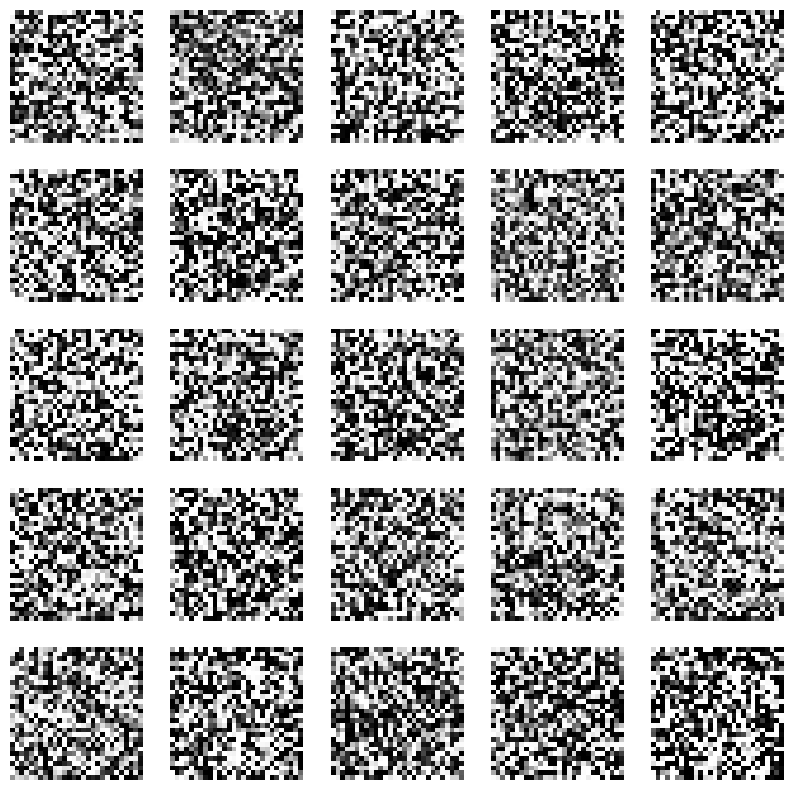

In [8]:
!pip install matplotlib
import matplotlib.pyplot as plt 

def sample_images(generator, epoch, num_images=25): 
    noise = np.random.normal(0, 1, (num_images, 100)) 
    generated_images = generator.predict(noise) 
    generated_images = 0.5 * generated_images + 0.5  # Rescale to [0, 1] 
    fig, axs = plt.subplots(5, 5, figsize=(10, 10)) 
    count = 0 

    for i in range(5): 
        for j in range(5): 
            axs[i, j].imshow(generated_images[count, :, :, 0], cmap='gray') 
            axs[i, j].axis('off') 
            count += 1 
    plt.show() 

# Sample images at the end of training 
sample_images(generator, epochs)


Görsel inceleme kullanarak, oluşturulan görüntülerdeki sorunları hızlıca belirleyebilirsiniz. Bulanıklık, yapı eksikliği veya çeşitlilik eksikliği fark ederseniz, model mimarisini veya eğitim parametrelerini ayarlamayı düşünün.

### 2. Nicel Değerlendirme: Metrikler

Görsel inceleme, GAN'ın performansına dair sezgisel bir anlayış sağlasa da, öznel olabilir. GAN performansını objektif olarak değerlendirmek için aşağıdaki gibi nicel metrikler kullanabilirsiniz:

- **Inception Skoru (IS)**: Bu skor, her bir görüntünün sınıfını tahmin etmek için önceden eğitilmiş bir sınıflandırıcı (Inception-v3 gibi) kullanarak oluşturulan görüntülerin hem kalitesini hem de çeşitliliğini ölçer. Daha yüksek bir skor, görüntülerin hem yüksek kaliteli hem de çeşitli olduğunu gösterir. Bununla birlikte, IS, MNIST gibi basit veri kümeleri için çok etkili değildir; daha çok karmaşık veri kümeleri için uygundur.

- **Fréchet Inception Mesafesi (FID)**: Bu metrik, oluşturulan görüntülerin ve gerçek görüntülerin dağılımları arasındaki mesafeyi hesaplar. Daha düşük bir FID puanı, üretilen görüntülerin gerçek görüntülere daha benzer olduğunu gösterir. FID, GAN performansını değerlendirmek için yaygın olarak kullanılan ve güvenilir bir ölçüt olarak kabul edilen bir metriktir.

- **Ayırıcı Doğruluğu**: Eğitim sırasında, ayırıcının doğruluğu %50 civarındaysa, üreticinin gerçek görüntülerden ayırt edilmesi zor, gerçekçi görüntüler ürettiğini gösterir. Bu metrik uygulaması kolaydır ve eğitim ilerlemesi hakkında hızlı geri bildirim sağlar.

### Talimatlar:

Sağlanan kod parçacığını kullanarak hem gerçek hem de sahte görüntülerde ayırıcının doğruluğunu hesaplayabilirsiniz.

In [9]:
# Calculate and print the discriminator accuracy on real vs. fake images
noise = np.random.normal(0, 1, (batch_size, 100))
generated_images = generator.predict(noise)

# Evaluate the discriminator on real images
real_images = x_train[np.random.randint(0, x_train.shape[0], batch_size)]
d_loss_real = discriminator.evaluate(real_images, np.ones((batch_size, 1)), verbose=0)

# Evaluate the discriminator on fake images
d_loss_fake = discriminator.evaluate(generated_images, np.zeros((batch_size, 1)), verbose=0)

print(f"Discriminator Accuracy on Real Images: {d_loss_real[1] * 100:.2f}%")
print(f"Discriminator Accuracy on Fake Images: {d_loss_fake[1] * 100:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Discriminator Accuracy on Real Images: 100.00%
Discriminator Accuracy on Fake Images: 100.00%


Ayırıcının doğruluğu %50 civarındaysa, bu, üreticinin gerçekçi görüntüler üretmeyi öğrendiği anlamına gelir. Daha yüksek veya daha düşük doğruluk, üreticinin ikna edici görüntüler üretmediğini veya ayırıcının aşırı uyum sağladığını gösterebilir.

### 3. Niteliksel ve Niceliksel Değerlendirmelerin Birleştirilmesi

GAN'ın kapsamlı bir değerlendirmesi için:

1. Görüntü kalitesi hakkında hızlı bir fikir edinmek için **görsel incelemeyle başlayın**. Görüntüler bulanık veya çok benzer görünüyorsa, eğitim sürecinde sorunlar olduğunu gösterebilir.

2. GAN'ın performansına ilişkin objektif kanıt sağlamak için FID veya ayırıcı doğruluğu gibi **nicel metrikler kullanın**.

3. Üretici ve ayırıcı kayıplarını zaman içinde görselleştirerek **eğitim ilerlemesini izleyin**. Bu, GAN'ın kararsızlıktan muzdarip olup olmadığını veya bir modelin diğerini alt edip etmediğini anlamaya yardımcı olur.

#### Açıklama:

Niteliksel inceleme ve niceliksel ölçütleri birleştirerek, GAN'lar tarafından üretilen görüntülerin kalitesini etkili bir şekilde değerlendirebilirsiniz. Bu ikili yaklaşım, daha sağlam bir değerlendirme sağlayarak, üretilen verilerin yalnızca görsel olarak makul değil, aynı zamanda gerçek verilere istatistiksel olarak benzer olmasını da garanti eder. GAN'ın performansını daha da iyileştirmek için farklı mimariler, öğrenme oranları ve eğitim parametreleriyle deneyler yapın.

# Alıştırmalar

### Alıştırma 1: Üreticinin mimarisini değiştirme

#### Amaç:
- Ağın derinliğinin üretilen görüntülerin kalitesini nasıl etkilediğini anlamak için üreticiye daha fazla katman eklemeyi deneyin.

#### Talimatlar:
1. Üretici modeline 2048 birimli bir Yoğun katman daha ekleyin.

2. Üreticiyi yeniden oluşturun ve özeti yazdırın.

In [10]:
def build_generator(): 
    model = Sequential() 
    model.add(Dense(256, input_dim=100)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(1024)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(2048))  # New layer added 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(28 * 28 * 1, activation='tanh')) 
    model.add(Reshape((28, 28, 1))) 
    return model 

# Rebuild the generator 
generator = build_generator() 
generator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 784)            │     1,606,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,403,728 (16.80 MB)

 Trainable params: 4,396,048 (16.77 MB)

 Non-trainable params: 7,680 (30.00 KB)

<details>
    <summary>Click here for Solution</summary>

```python
# Modify the generator model by adding an additional Dense layer 

def build_generator(): 
    model = Sequential() 
    model.add(Dense(256, input_dim=100)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(1024)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(2048))  # New layer added 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(BatchNormalization(momentum=0.8)) 
    model.add(Dense(28 * 28 * 1, activation='tanh')) 
    model.add(Reshape((28, 28, 1))) 
    return model 

# Rebuild the generator 
generator = build_generator() 
generator.summary() 
```

</details>


### Alıştırma 2 - Ayırıcının öğrenme oranını ayarlama

#### Amaç:

- Ayırıcının optimize edicisinin öğrenme oranının değiştirilmesinin eğitim istikrarını ve model performansını nasıl etkilediğini incelemek.

#### Talimatlar:
1. Ayırıcı için Adam optimize edicisinin öğrenme oranını 0,0002 olarak değiştirin.

2. Ayırıcıyı yeni öğrenme oranıyla yeniden oluşturun ve derleyin.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LeakyReLU

def build_discriminator(): 
    model = Sequential() 
    model.add(Flatten(input_shape=(28, 28, 1))) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(256)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(1, activation='sigmoid')) 
    return model 

# Rebuild and compile the discriminator with a lower learning rate 
discriminator = build_discriminator() 
discriminator.compile(loss='binary_crossentropy', 
                      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), 
                      metrics=['accuracy']) 

discriminator.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

<details>
    <summary>Click here for Solution</summary>

```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LeakyReLU

def build_discriminator(): 
    model = Sequential() 
    model.add(Flatten(input_shape=(28, 28, 1))) 
    model.add(Dense(512)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(256)) 
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(1, activation='sigmoid')) 
    return model 

# Rebuild and compile the discriminator with a lower learning rate 
discriminator = build_discriminator() 
discriminator.compile(loss='binary_crossentropy', 
                      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), 
                      metrics=['accuracy']) 

discriminator.summary()

```

</details>


### Alıştırma 3 - Eğitim İlerlemesini Görselleştirme

#### Amaç:
- Eğitim sürecini izlemek için, eğitim sırasında ayırıcı ve üreticinin kayıplarını görselleştirmek.

#### Talimatlar:
1. Ayırıcı ve üretici kayıplarını saklamak için eğitim döngüsünü değiştirin.

2. Eğitim ilerlemesini görselleştirmek için eğitimden sonraki kayıpları çizin.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 
0 [D loss: 0.6365275084972382] [D accuracy: 60.546875] [G loss: 0.017080573365092278]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
10 [D loss: 0.267651230096817] [D accuracy: 91.85606241226196] [G loss: 0.016317054629325867]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
20 [D loss: 0.1638323

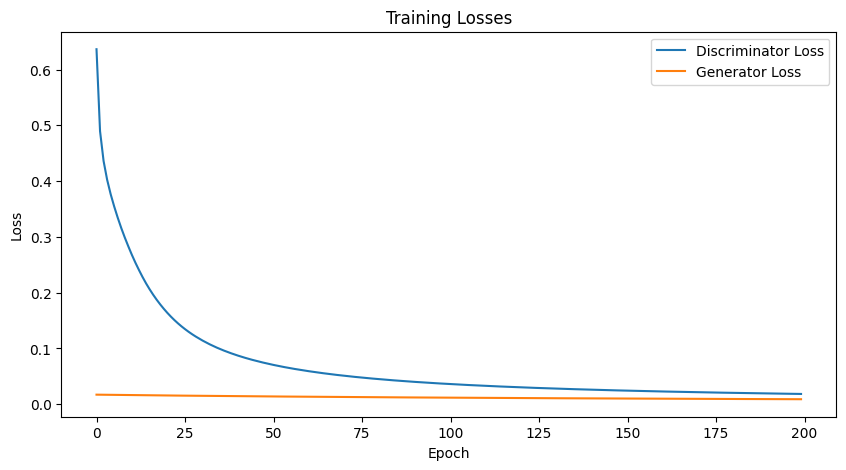

In [12]:
d_losses = [] 
g_losses = [] 

 
# Training loop with loss storage 
for epoch in range(epochs): 
    idx = np.random.randint(0, x_train.shape[0], batch_size) 
    real_images = x_train[idx] 
    noise = np.random.normal(0, 1, (batch_size, 100)) 
    generated_images = generator.predict(noise) 
    d_loss_real = discriminator.train_on_batch(real_images, real) 
    d_loss_fake = discriminator.train_on_batch(generated_images, fake) 
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake) 
    d_losses.append(d_loss[0]) 
  

    noise = np.random.normal(0, 1, (batch_size, 100)) 
    g_loss = gan.train_on_batch(noise, real) 
    g_losses.append(g_loss) 

  
    if epoch % sample_interval == 0: 
        print(f"{epoch} [D loss: {d_loss[0]}] [D accuracy: {100 * d_loss[1]}] [G loss: {g_loss}]") 
  
# Plot the training losses 
plt.figure(figsize=(10, 5)) 
plt.plot(d_losses, label='Discriminator Loss') 
plt.plot(g_losses, label='Generator Loss') 
plt.xlabel('Epoch') 
plt.ylabel('Loss') 
plt.title('Training Losses') 
plt.legend() 
plt.show()